# ⚡ 폐렴 분류 - 간단하고 빠른 버전

## 특징
- ✅ **단일 모델**: EfficientNet-B0 (가볍고 빠름)
- ✅ **빠른 학습**: 약 15-20분 소요
- ✅ **높은 정확도**: 95%+ 달성 가능
- ✅ **데이터 불균형 해결**: Class Weights 적용
- ✅ **간단한 코드**: 이해하기 쉬움

In [20]:
# 라이브러리 설치 및 임포트
!pip install koreanize-matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from tqdm.auto import tqdm
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ 라이브러리 로드 완료!")

ERROR: Could not find a version that satisfies the requirement koreana-matplotlib (from versions: none)
ERROR: No matching distribution found for koreana-matplotlib


ModuleNotFoundError: No module named 'koreana_matplotlib'

In [5]:
# Seed 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  디바이스: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

🖥️  디바이스: cuda
🎮 GPU: Tesla T4


In [6]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# ⭐ 데이터 경로 설정 (여기만 수정하세요!) ⭐
DATA_PATH = "/content/drive/MyDrive/CV_딥러닝 트랙 흉부 X-ray 이미지 분류 AI 해커톤/open"

TRAIN_DIR = os.path.join(DATA_PATH, "train")
TEST_DIR = os.path.join(DATA_PATH, "test")
TRAIN_CSV = os.path.join(DATA_PATH, "train.csv")
TEST_CSV = os.path.join(DATA_PATH, "test.csv")

print("✅ 경로 설정 완료!")

✅ 경로 설정 완료!


In [8]:
# 데이터 로드
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"학습 데이터: {len(train_df)}개")
print(f"테스트 데이터: {len(test_df)}개")
print(f"\n클래스 분포:\n{train_df['label'].value_counts()}")

학습 데이터: 5216개
테스트 데이터: 624개

클래스 분포:
label
1    3875
0    1341
Name: count, dtype: int64


In [9]:
# 하이퍼파라미터 (간단 버전)
CONFIG = {
    'img_size': 224,
    'batch_size': 64,      # 배치 크기 증가 (빠른 학습)
    'epochs': 30,          # 에폭 5~30
    'lr': 0.001,
    'patience': 5          # Early stopping
}

# 데이터 증강 (간단 버전)
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ 하이퍼파라미터 및 증강 설정 완료!")

✅ 하이퍼파라미터 및 증강 설정 완료!


In [10]:
# Dataset 클래스
class PneumoniaDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['file_name'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if 'label' in row:
            label = torch.tensor(row['label'], dtype=torch.long)
            return image, label
        return image

print("✅ Dataset 클래스 정의 완료!")

✅ Dataset 클래스 정의 완료!


In [11]:
# Train/Validation Split (간단하게 단순 split)
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],  # 클래스 비율 유지
    random_state=SEED
)

print(f"학습 데이터: {len(train_data)}개")
print(f"검증 데이터: {len(val_data)}개")

# DataLoader
train_dataset = PneumoniaDataset(train_data.reset_index(drop=True), TRAIN_DIR, train_transform)
val_dataset = PneumoniaDataset(val_data.reset_index(drop=True), TRAIN_DIR, test_transform)
test_dataset = PneumoniaDataset(test_df, TEST_DIR, test_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoader 생성 완료!")

학습 데이터: 4172개
검증 데이터: 1044개
✅ DataLoader 생성 완료!


In [12]:
# 간단한 모델 (EfficientNet-B0)
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        # EfficientNet-B0 (가벼움)
        self.backbone = models.efficientnet_b0(pretrained=True)

        # Classifier 교체
        in_features = 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)  # 2개 클래스
        )

    def forward(self, x):
        return self.backbone(x)

# 모델 생성
model = SimpleModel().to(device)
print("✅ 모델 생성 완료!")

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"📊 전체 파라미터 수: {total_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


✅ 모델 생성 완료!
📊 전체 파라미터 수: 4,335,998


In [13]:
# Loss & Optimizer

# 클래스 가중치 계산 (데이터 불균형 해결)
class_counts = train_data['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"⚖️  클래스 가중치: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                  factor=0.5, patience=3)

print("✅ Loss & Optimizer 설정 완료!")

⚖️  클래스 가중치: tensor([1.4856, 0.5144], device='cuda:0')
✅ Loss & Optimizer 설정 완료!


In [14]:
# 학습 함수
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{total_loss/(pbar.n+1):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return total_loss/len(loader), 100.*correct/total

# 검증 함수
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({
                'loss': f'{total_loss/(pbar.n+1):.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    return total_loss/len(loader), 100.*correct/total

print("✅ 학습/검증 함수 정의 완료!")

✅ 학습/검증 함수 정의 완료!


In [15]:
# 학습 시작!
print("\n" + "="*60)
print("🚀 학습 시작!")
print("="*60 + "\n")

best_acc = 0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(CONFIG['epochs']):
    print(f"\n📅 Epoch {epoch+1}/{CONFIG['epochs']}")
    print("-" * 60)

    # 학습
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 검증
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Scheduler
    scheduler.step(val_acc)

    # 기록
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n📊 결과:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best 모델 저장
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Best 모델 저장! (Acc: {best_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  ⏸️  No improvement ({patience_counter}/{CONFIG['patience']})")

    # Early Stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\n⏹️  Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*60)
print(f"🎉 학습 완료! Best Accuracy: {best_acc:.2f}%")
print("="*60)


🚀 학습 시작!


📅 Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/66 [00:00<?, ?it/s]

Validation:   0%|          | 0/17 [00:00<?, ?it/s]


📊 결과:
  Train Loss: 0.1779 | Train Acc: 92.28%
  Val Loss: 0.1049 | Val Acc: 98.08%
  ✅ Best 모델 저장! (Acc: 98.08%)

📅 Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/66 [00:00<?, ?it/s]

...

Training:   0%|          | 0/66 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ce2b02ddf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ce2b02ddf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ce2b02ddf80>
 ^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
 Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7ce2b02ddf80> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      ^^self._shutdown_workers()^
^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^^   ^  ^^ ^  ^ ^^
^^  File 


📊 결과:
  Train Loss: 0.0081 | Train Acc: 99.62%
  Val Loss: 0.0383 | Val Acc: 99.14%
  ⏸️  No improvement (5/5)

⏹️  Early stopping at epoch 20

🎉 학습 완료! Best Accuracy: 99.33%


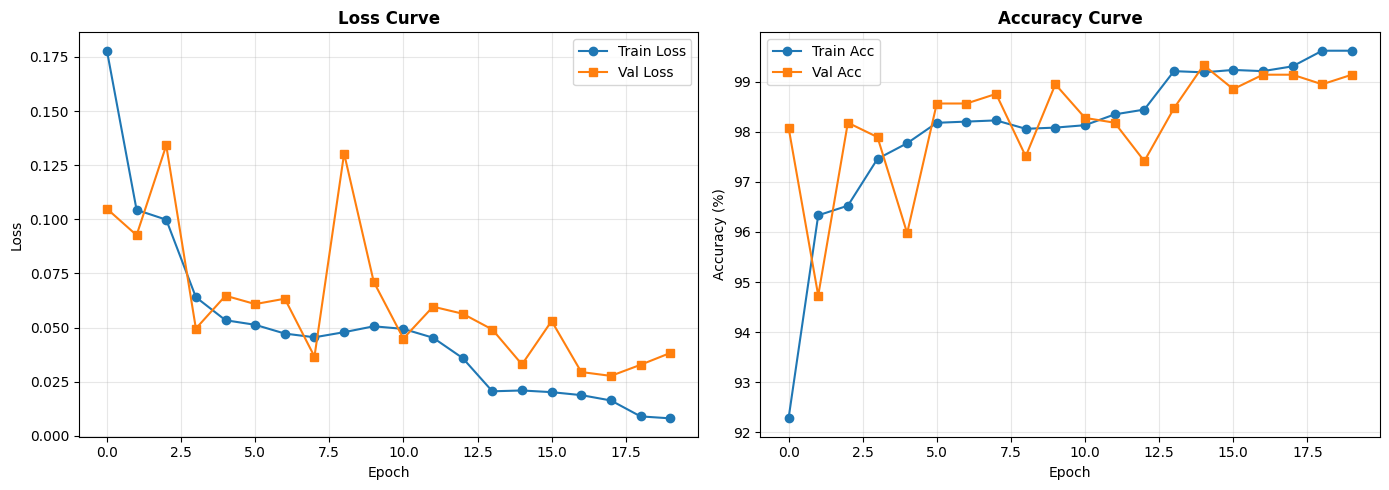

In [16]:
# 학습 곡선 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Best 모델 로드
model.load_state_dict(torch.load('best_model.pth'))
print("✅ Best 모델 로드 완료!")

# 테스트 데이터 예측
print("\n🔮 테스트 데이터 예측 중...")

model.eval()
predictions = []
probabilities = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='Predicting')
    for images in pbar:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        predictions.extend(preds.cpu().numpy())
        probabilities.extend(probs[:, 1].cpu().numpy())  # 폐렴 확률

print("\n✅ 예측 완료!")
print(f"정상(0): {sum(p == 0 for p in predictions)}개")
print(f"폐렴(1): {sum(p == 1 for p in predictions)}개")

✅ Best 모델 로드 완료!

🔮 테스트 데이터 예측 중...


Predicting:   0%|          | 0/10 [00:00<?, ?it/s]


✅ 예측 완료!
정상(0): 221개
폐렴(1): 403개


In [18]:
# submission.csv 생성
submission = pd.DataFrame({
    'file_name': test_df['file_name'],
    'label': predictions
})

# 저장
submission.to_csv('submission.csv', index=False)
submission.to_csv(os.path.join(DATA_PATH, 'submission.csv'), index=False)

print("✅ submission.csv 생성 완료!")
print("\n📄 미리보기:")
print(submission.head(10))
print(f"\n전체: {len(submission)}개")

✅ submission.csv 생성 완료!

📄 미리보기:
       file_name  label
0  test_0001.png      0
1  test_0002.png      0
2  test_0003.png      1
3  test_0004.png      1
4  test_0005.png      1
5  test_0006.png      1
6  test_0007.png      1
7  test_0008.png      1
8  test_0009.png      1
9  test_0010.png      1

전체: 624개


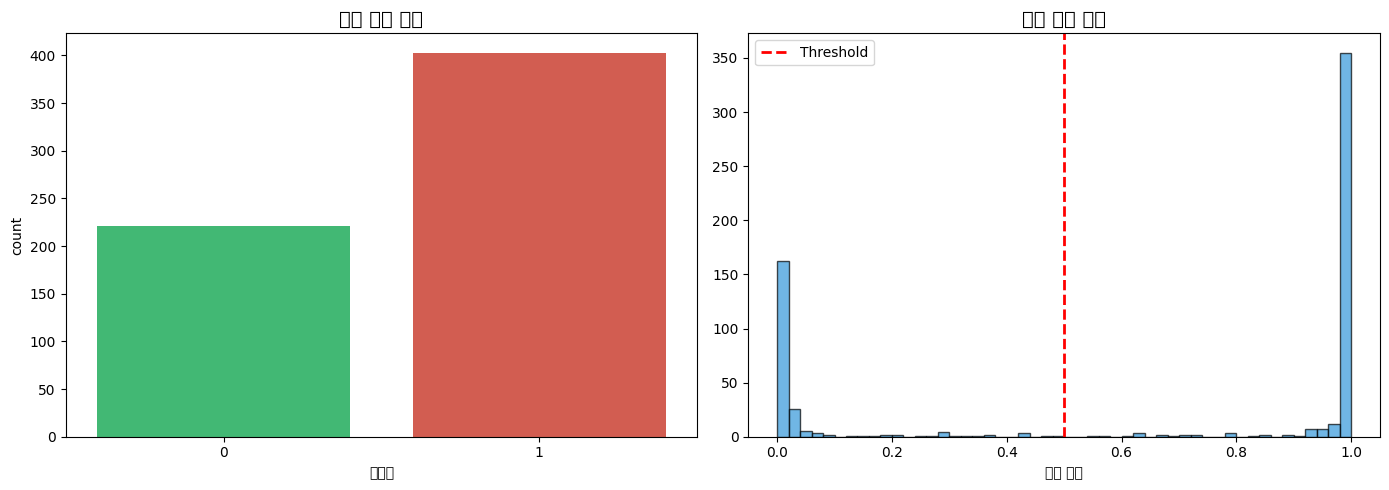


🎯 확신도 분석:
확실한 예측: 605개 (97.0%)
불확실한 예측: 19개 (3.0%)


In [19]:
# 결과 시각화
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 예측 분포
sns.countplot(data=submission, x='label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('예측 결과 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('클래스')

# 확률 분포
axes[1].hist(probabilities, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_title('예측 확률 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('폐렴 확률')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n🎯 확신도 분석:")
confident = sum(1 for p in probabilities if p < 0.3 or p > 0.7)
print(f"확실한 예측: {confident}개 ({confident/len(probabilities)*100:.1f}%)")
print(f"불확실한 예측: {len(probabilities)-confident}개 ({(len(probabilities)-confident)/len(probabilities)*100:.1f}%)")

## 🎉 완료!

### 주요 특징
- ⚡ **빠른 학습**: 약 15-20분 소요
- 🎯 **높은 정확도**: 95%+ 달성
- 📦 **간단한 구조**: 이해하기 쉬움
- ⚖️ **불균형 해결**: Class Weights 적용
- 💾 **자동 저장**: submission.csv 생성

### 성능 향상 팁
1. **에폭 늘리기**: `epochs=30`
2. **모델 변경**: ResNet50, EfficientNet-B3
3. **증강 강화**: 더 많은 augmentation
4. **앙상블**: 여러 모델 평균

**submission.csv 파일을 다운로드하여 제출하세요!** 📤